# CIP — Primal Integrity Cipher

## Public Digital Integrity Protocol

### Operational Demonstration in Python

This notebook is a functional artefact; its mathematical foundations are documented in the cited references.

It provides a reproducible and verifiable demonstration of the CIP (Primal Integrity Cipher) protocol, as implemented by the official binary.

The four fundamental verbs of the protocol are documented:

1. **assinar** — deterministic integrity signature computation;
2. **verificar** — independent validation of coherence between file and key;
3. **cifrar** — deterministic transformation for reversible confidentiality;
4. **decifrar** — reconstruction of the original file with verification.

The demonstration uses the CIP binary in a public execution environment (Google Colab), operating in demonstration mode.

In institutional or commercial contexts, verification and decryption operations may be regulated by an internal credit counter, stored and protected by the protocol itself and verified at each execution.

> **Note**
> This notebook does not expose sensitive material, cryptographic secrets, or private keys.  
> The CIP protocol operates exclusively on public mathematical structure, deterministic vector projections, and explicit chaining of SHA-256 hashes.  
> There is no use of seeds, external randomness, hidden state, or dependence on a central authority.


## CIP Protocol Operating Modes

The CIP protocol admits two formal operating regimes.

Both use the same arithmetic operator and the same spectral projection mechanism.
The differences between the regimes concern exclusively the extent of structural observation and the artefacts produced.

The distinction between these regimes is necessary for auditing, technical documentation, and consistent institutional use.

---

### 1. Standard Mode (default, without `-t`)

Standard mode performs optimised structural verification.

* Evaluates 15 file blocks, distributed as:

  * 5 initial blocks
  * 5 central blocks
  * 5 final blocks
* Generated keys are compact.
* Suitable for high-volume operations and recurrent validations.
* Detects structurally relevant alterations in file content.

**Summary:**

> Operational efficiency with consistent structural coverage.

---

### 2. Total Mode (`-t`)

Total mode performs full structural verification.

* Evaluates 100% of the file blocks.
* Explicitly embeds the projection basis representation into the key.
* Generates a signature sufficient for future verification independent of the generation environment.
* Enables full interoperability between SDKs with distinct indices.

This regime is appropriate when integrity must be demonstrable outside the original signing context, including long-term audits and cross-environment validation.

**Summary:**

> Complete, deterministic, and platform-independent verification.

---

### Objective Comparison

| Property                       | Standard Mode | Total Mode    |
| ------------------------------ | ------------- | ------------- |
| Blocks evaluated               | 15 (5+5+5)    | 100%          |
| Projection basis in key        | Implicit      | Explicit      |
| Key size                       | Smaller       | Larger        |
| Primary purpose                | Operational   | Institutional |
| Custody transparency           | Adequate      | Recommended   |
| Interoperability               | Full          | Full          |
| Sensitivity to minimal changes | Partial       | Complete      |

---

### Automatic Regime Identification

When loading a key, the binary automatically identifies the generation regime and reports:

* Key generated in TOTAL mode (`-t`)
  or
* Key generated in STANDARD mode.

This automatic identification removes ambiguity and ensures proper traceability in audits and technical reports.


## 1. Prerequisites

To execute this notebook correctly, the following are required:

* the `cip` binary compiled for Linux (Ubuntu), compatible with the Google Colab environment;
* the CIP SDK demonstration package properly extracted;
* Python 3 with Jupyter Notebook or Jupyter Lab (the default Colab environment is sufficient).

Within this Zenodo publication, two official English versions of the CIP binary are provided, both compiled for Linux (Ubuntu), differing only by their internal spectral index:

* CIP SDK – IDX 0
* CIP SDK – IDX 6

These two versions make it possible to demonstrate, in a controlled and verifiable manner, the interoperability of the CIP protocol between SDKs with distinct indices.

> **Structural Note**
> The CIP protocol does not use PKI infrastructure.
> It does not depend on digital certificates, RSA/ECDSA signatures, external private keys, or certification authorities.
> Integrity verification is performed exclusively through public mathematical structure, vector projection, and explicit chaining of SHA-256 hashes.

Next, the basic paths and utilities required for executing the examples are configured.

---

## Path and Utility Configuration (Python)

In the following cells, the notebook will:

* locate the `cip` binary corresponding to the selected SDK (IDX 0 or IDX 6);
* define temporary working directories;
* prepare auxiliary functions for controlled execution of protocol commands.

This explicit separation of paths avoids ambiguity, facilitates auditing, and ensures reproducibility of the demonstration.


In [1]:
# =================================================================
# CÉLULA 1 - Download of CIP SDKs (IDX 0 and IDX 6)
# =================================================================

!wget -q -O cip-sdk-linux-idx0-en.zip https://delta-cip.com.br/downloads/cip-sdk-linux-idx0-en.zip
!unzip -o -q cip-sdk-linux-idx0-en.zip -d /content/

!wget -q -O cip-sdk-linux-idx6-en.zip https://delta-cip.com.br/downloads/cip-sdk-linux-idx6-en.zip
!unzip -o -q cip-sdk-linux-idx6-en.zip -d /content/

!echo "CIP SDKs (IDX 0 and IDX 6) downloaded and extracted successfully."


CIP SDKs (IDX 0 and IDX 6) downloaded and extracted successfully.


### Code — Execution and identification of the CIP binary version

In [2]:
# =================================================================
# CELL 2 - Initialisation of both SDKs (IDX 0 and IDX 6)
# =================================================================

import os
import subprocess
from pathlib import Path

def initialise_sdk(sdk_name):
    sdk_path = Path(f"/content/{sdk_name}")
    cip_bin = sdk_path / "bin" / "cip"

    assert cip_bin.exists(), f"CIP binary not found at {cip_bin}"

    # Ensure executable permission
    os.chmod(cip_bin, 0o755)

    # Execute once to display identification banner
    proc = subprocess.run(
        ["./bin/cip"],
        cwd=sdk_path,
        capture_output=True,
        text=True
    )

    print(f"=== {sdk_name} ===")
    print(proc.stdout)
    print("Environment initialised successfully.\n")

    return sdk_path

# Initialisation of both SDKs
SDK_IDX0 = initialise_sdk("cip-sdk-linux-idx0-en")
SDK_IDX6 = initialise_sdk("cip-sdk-linux-idx6-en")


=== cip-sdk-linux-idx0-en ===
[INFO] OpenMP threads: 1
[INFO] Eigen threads: 1

════════════════[ CIP - SDK Configuration ]═════════════════
[INFO] SDK idx fixed by build: 0
[SUCCESS] SDK configuration (idx 0) loaded successfully.
[INFO] Signing matrix idx: 0 | Encryption matrix idx: 1

Usage: cip <action> [arguments...]

Available actions (TOTAL mode via -t):
────────────────────────────────────────────────────────────
  assinar    <file> [-c "comment"] [-t]	Generate a spectral signature.
  verificar  <file> <key.json> [-c "comment"] [-t]	Verify spectral integrity.
  cifrar     <file> [-c "comment"] [-t]	Encrypt file with traceability.
  decifrar   <file.cip> <key.json> [-c "comment"] [-t]	Decrypt and validate content.

Use --help or -h for full documentation.


Environment initialised successfully.

=== cip-sdk-linux-idx6-en ===
[INFO] OpenMP threads: 1
[INFO] Eigen threads: 1

════════════════[ CIP - SDK Configuration ]═════════════════
[INFO] SDK idx fixed by build: 6
[SUCCESS] SDK

### Explanatory note

#### On identification of the CIP protocol version

The CIP protocol **does not expose an explicit version command**.

This is a deliberate design choice.

The identity of a CIP SDK is not defined by a textual version number, but by its **effective runtime configuration**, including:

* the loaded harmonic index (IDX);
* the operational mode (credit counter enabled or unlimited);
* the available signing and encryption matrices.

This information is automatically displayed whenever the binary is executed, before any operation is performed.

When running:

```bash
./bin/cip
```

the SDK explicitly reports:

* the determined IDX;
* the associated matrices;
* the execution regime.

There is therefore no ambiguity and no dependency on external documentation.
**The binary describes itself by what it executes, not by a textual label.**

---

### Methodological note

This notebook uses two distinct CIP SDK instances, each based on a different harmonic index (`IDX 0` and `IDX 6`).

The objective is **not redundancy**, but structural demonstration:

* one SDK performs signing;
* the other performs verification;

and then the roles are inverted.

This demonstrates that integrity is **not coupled to the software**, but to the **mathematical structure embedded in the key**.

In other words:
**the entity that signs does not need to be the entity that verifies.**


In [3]:
# =================================================================
# CELL 3 - Self-contained preparation of the CIP SDK (Colab / Linux)
# =================================================================

import os
import stat
import zipfile
import subprocess
from pathlib import Path

# ------------------------------------------------------------
# 1. Notebook base directory
# ------------------------------------------------------------
BASE_DIR = Path.cwd()
print(f"[INFO] Notebook base directory: {BASE_DIR}")

# ------------------------------------------------------------
# 2. Definition of SDKs to be used
# ------------------------------------------------------------
SDKS = {
    "idx0": {
        "zip": "cip-sdk-linux-idx0-en.zip",
        "dir": "cip-sdk-linux-idx0-en",
        "url": "https://delta-cip.com.br/downloads/cip-sdk-linux-idx0-en.zip",
    },
    "idx6": {
        "zip": "cip-sdk-linux-idx6-en.zip",
        "dir": "cip-sdk-linux-idx6-en",
        "url": "https://delta-cip.com.br/downloads/cip-sdk-linux-idx6-en.zip",
    },
}

# ------------------------------------------------------------
# 3. Download and extraction (if necessary)
# ------------------------------------------------------------
for label, cfg in SDKS.items():
    zip_path = BASE_DIR / cfg["zip"]
    sdk_dir = BASE_DIR / cfg["dir"]

    if not sdk_dir.exists():
        print(f"[INFO] Preparing CIP SDK ({label})...")
        if not zip_path.exists():
            subprocess.run(
                ["wget", "-q", "-O", cfg["zip"], cfg["url"]],
                check=True
            )
            print(f"[OK] Downloaded {cfg['zip']}")

        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(BASE_DIR)
        print(f"[OK] Extracted {cfg['dir']}")
    else:
        print(f"[OK] SDK already present: {cfg['dir']}")

# ------------------------------------------------------------
# 4. Binary validation
# ------------------------------------------------------------
for label, cfg in SDKS.items():
    cip_bin = BASE_DIR / cfg["dir"] / "bin" / "cip"
    if not cip_bin.exists():
        raise FileNotFoundError(f"CIP binary not found: {cip_bin}")

    os.chmod(cip_bin, os.stat(cip_bin).st_mode | stat.S_IXUSR)
    print(f"[OK] CIP binary ready ({label}): {cip_bin}")

# ------------------------------------------------------------
# 5. Working directory
# ------------------------------------------------------------
DATA_DIR = BASE_DIR / "sample_data"
DATA_DIR.mkdir(exist_ok=True)
print(f"[OK] Working directory: {DATA_DIR}")

STRESS_DIR = BASE_DIR / "stress_test"
STRESS_DIR.mkdir(exist_ok=True)

# ------------------------------------------------------------
# 6. Documented operational limit
# ------------------------------------------------------------
LIMITE_BYTES = 1 * 1024 * 1024 * 1024  # 1 GB
print(f"[INFO] Operational file size limit: {LIMITE_BYTES / (1024**3):.1f} GB")

print(
    "\nNote:\n"
    "This notebook deliberately uses two distinct SDKs (IDX 0 and IDX 6).\n"
    "Signatures generated by one will be verified by the other,\n"
    "demonstrating structural interoperability and software independence."
)

# ============================================================
# Explicit mapping of SDKs for use in subsequent cells
# ============================================================

SDK_IDX0_DIR = BASE_DIR / SDKS["idx0"]["dir"]
SDK_IDX6_DIR = BASE_DIR / SDKS["idx6"]["dir"]

CIP_IDX0_BIN = SDK_IDX0_DIR / "bin" / "cip"
CIP_IDX6_BIN = SDK_IDX6_DIR / "bin" / "cip"


[INFO] Notebook base directory: /content
[OK] SDK already present: cip-sdk-linux-idx0-en
[OK] SDK already present: cip-sdk-linux-idx6-en
[OK] CIP binary ready (idx0): /content/cip-sdk-linux-idx0-en/bin/cip
[OK] CIP binary ready (idx6): /content/cip-sdk-linux-idx6-en/bin/cip
[OK] Working directory: /content/sample_data
[INFO] Operational file size limit: 1.0 GB

Note:
This notebook deliberately uses two distinct SDKs (IDX 0 and IDX 6).
Signatures generated by one will be verified by the other,
demonstrating structural interoperability and software independence.


## Large public file for structural integrity testing

In this step, we use a **public, stable, and large-scale file** as the test object for the structural integrity verified by the CIP protocol.

The selected file is the **NOAA Global Summary of the Day (GSOD)** dataset for the year 2023, with approximately **100 MB**. This dataset is widely used in climatology, scientific auditing, and historical preservation, and is distributed by an international public institution.

The choice of this file is deliberate:

* it **was not generated for this experiment**;
* it is **outside the author’s control**;
* it is **identical for anyone, anywhere**;
* it is large enough to represent real-world scenarios such as:

  * institutional backups,
  * consolidated logs,
  * system images,
  * long-term digital preservation artefacts.

By employing a file of this nature, the experiment demonstrates that:

* the CIP protocol does not rely on artificial examples or trivial files;
* integrity verification operates deterministically on large datasets;
* minimal alterations — including a **single-bit change** — are detected unambiguously.

This file will be used in the next cells for:

1. signing in TOTAL mode;
2. cross-verification between SDKs with distinct indices;
3. minimal corruption testing (1 bit);
4. demonstration of structural interoperability.

The following cell ensures local availability of the file, downloading it only if necessary.

In [4]:
# ==============================================================
# CELL 4 - Download of a large public file (NOAA ~100 MB)
# ==============================================================

import requests
from tqdm import tqdm

# Public, stable NOAA file, sufficiently large for integrity tests
URL_GRANDE = "https://www.ncei.noaa.gov/data/global-summary-of-the-day/archive/2023.tar.gz"
arquivo_grande = STRESS_DIR / "noaa_gsod_2023.tar.gz"

print(f"[INFO] Target local file: {arquivo_grande}")

# ------------------------------------------------------------
# 1. Check for prior existence
# ------------------------------------------------------------
if arquivo_grande.exists():
    tamanho = arquivo_grande.stat().st_size
    print(f"[OK] File found locally ({tamanho/1e6:.1f} MB).")

else:
    # --------------------------------------------------------
    # 2. Download with progress bar
    # --------------------------------------------------------
    print("\n[INFO] Starting download of public file for integrity testing.")
    print(f"[INFO] Official NOAA source: {URL_GRANDE}")
    print(f"[INFO] Local destination: {arquivo_grande}\n")

    with requests.get(URL_GRANDE, stream=True, timeout=60) as r:
        r.raise_for_status()

        tamanho_total = int(r.headers.get("Content-Length", 0))
        bloco = 1_048_576  # 1 MB

        with open(arquivo_grande, "wb") as f, tqdm(
            total=tamanho_total if tamanho_total > 0 else None,
            unit="B",
            unit_scale=True,
            unit_divisor=1024,
            desc="Downloading NOAA GSOD 2023",
            miniters=1
        ) as barra:

            for chunk in r.iter_content(chunk_size=bloco):
                if chunk:
                    f.write(chunk)
                    barra.update(len(chunk))

    tamanho = arquivo_grande.stat().st_size
    print(f"\n[OK] Download completed ({tamanho/1e6:.1f} MB).")

# ------------------------------------------------------------
# 3. Basic validations
# ------------------------------------------------------------
if tamanho == 0:
    raise RuntimeError("[ERROR] Download failure — zero-size file.")

if tamanho > LIMITE_BYTES:
    raise RuntimeError("[ERROR] File exceeds the limit defined for this demonstration.")

print(f"[OK] File within allowed limit ({LIMITE_BYTES/1e6:.1f} MB).")

# ------------------------------------------------------------
# 4. Institutional note
# ------------------------------------------------------------
print(
    "\n[INFO] The NOAA file (Global Summary of the Day) is public, stable, and external to the author’s control.\n"
    "[INFO] It will be used as the test object to demonstrate structural integrity verification\n"
    "[INFO] of the CIP protocol over large-scale data, in a realistic scenario."
)


[INFO] Target local file: /content/stress_test/noaa_gsod_2023.tar.gz

[INFO] Starting download of public file for integrity testing.
[INFO] Official NOAA source: https://www.ncei.noaa.gov/data/global-summary-of-the-day/archive/2023.tar.gz
[INFO] Local destination: /content/stress_test/noaa_gsod_2023.tar.gz




[OK] Download completed (108.8 MB).
[OK] File within allowed limit (1073.7 MB).

[INFO] The NOAA file (Global Summary of the Day) is public, stable, and external to the author’s control.
[INFO] It will be used as the test object to demonstrate structural integrity verification
[INFO] of the CIP protocol over large-scale data, in a realistic scenario.


### Initial Inspection and Creation of the Working Copy

At this stage, the **chain of custody of the experiment** is formally established.

The file obtained in the previous cell is treated as an **immutable reference artefact**.
All subsequent operations — signing, verification, and controlled corruption — are performed **exclusively on a working copy**, preserving the original file for:

* independent auditing;
* full reproducibility of the experiment;
* external verification by third parties.

This explicit separation between the **original artefact** and the **operational copy** reflects practices adopted in institutional, legal, and forensic contexts, in which the object under analysis must not be modified during experimental procedures.

Next, we will:

* validate the existence and size of the file;
* check compliance with the protocol’s operational limits;
* create the working copy that will be used in all CIP protocol demonstrations.


In [5]:
# ============================================================
# CELL 5 - Initial inspection and creation of the working copy
# ============================================================

import shutil
import hashlib

# File obtained in CELL 4
large_original_file = arquivo_grande

# ------------------------------------------------------------
# 1. Verify file existence
# ------------------------------------------------------------
if not large_original_file.exists():
    raise FileNotFoundError("[ERROR] Original file not found. Check CELL 4.")

print(f"[OK] File loaded for inspection: {large_original_file}")

# ------------------------------------------------------------
# 2. Basic file information
# ------------------------------------------------------------
size_bytes = large_original_file.stat().st_size
size_mb = size_bytes / 1e6

print(f"[INFO] Name................: {large_original_file.name}")
print(f"[INFO] Size (bytes)........: {size_bytes:,}")
print(f"[INFO] Size (MB)...........: {size_mb:.2f}")

# ------------------------------------------------------------
# 3. Security validations
# ------------------------------------------------------------
if size_bytes == 0:
    raise RuntimeError("[ERROR] Downloaded file has zero size.")

if size_bytes > LIMITE_BYTES:
    raise RuntimeError(
        f"[ERROR] File exceeds the permitted limit of 1 GB "
        f"({size_bytes/1e6:.1f} MB)."
    )

# ------------------------------------------------------------
# 4. Create working copy (chain of custody)
# ------------------------------------------------------------
STRESS_DIR.mkdir(exist_ok=True)
working_file = STRESS_DIR / f"{large_original_file.stem}_work{large_original_file.suffix}"

if not working_file.exists():
    shutil.copy2(large_original_file, working_file)
    print(f"[OK] Working copy created at: {working_file}")
else:
    print(f"[OK] Working copy already exists: {working_file}")

print(
    "[INFO] All modifications and corruptions will be performed exclusively on the working copy, "
    "preserving the original artefact for audit and reproducibility purposes."
)

def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

print(f"[INFO] SHA-256 (original) : {sha256_file(large_original_file)}")
print(f"[INFO] SHA-256 (working)  : {sha256_file(working_file)}")
print("[OK] Initial chain of custody established.")


[OK] File loaded for inspection: /content/stress_test/noaa_gsod_2023.tar.gz
[INFO] Name................: noaa_gsod_2023.tar.gz
[INFO] Size (bytes)........: 108,776,234
[INFO] Size (MB)...........: 108.78
[OK] Working copy created at: /content/stress_test/noaa_gsod_2023.tar_work.gz
[INFO] All modifications and corruptions will be performed exclusively on the working copy, preserving the original artefact for audit and reproducibility purposes.
[INFO] SHA-256 (original) : f2c9f7f672405bd1036f477a406cbb420ada33335f5e15c9bf9789210148d4d7
[INFO] SHA-256 (working)  : f2c9f7f672405bd1036f477a406cbb420ada33335f5e15c9bf9789210148d4d7
[OK] Initial chain of custody established.


## Signing the Original File in TOTAL Mode (`-t`)

At this stage, the original file is **formally signed** using the CIP protocol in **TOTAL mode (`-t`)**.

This is a central point of the experiment:

* the file acquires an **explicit spectral identity**;
* the signature is not a simple statistical digest, but a **full vectorial projection**;
* the projection matrix is **embedded directly into the CIPT key**, making the signature **self-sufficient** and **independent of future software versions**.

Unlike traditional PKI-based mechanisms, this signature:

* does not use private keys;
* does not rely on digital certificates;
* does not require a certification authority;
* is not subject to expiration, revocation, or external infrastructure.

The generated CIPT key contains **all information required for future verification**, including in:

* other computational environments;
* different builds;
* SDKs with different indices;
* independent institutional contexts.

Next:

* we execute the TOTAL-mode signature;
* we locate the generated CIPT key;
* and we inspect its structure for audit and transparency purposes.


In [6]:
# ============================================================
# CELL 6 - Signing the original file (SDK IDX 0, TOTAL mode)
# ============================================================

import time
import json
import subprocess

# ------------------------------------------------------------
# Explicit definition of the SDK that PERFORMS SIGNING
# ------------------------------------------------------------
SIGNING_SDK_DIR = SDK_IDX0_DIR
CIP_SIGNING_BIN = CIP_IDX0_BIN

assert SIGNING_SDK_DIR.exists(), "[ERROR] SDK IDX 0 directory not found."
assert CIP_SIGNING_BIN.exists(), "[ERROR] CIP IDX 0 binary not found."

# ------------------------------------------------------------
# Utility function
# ------------------------------------------------------------
def run_cip(cip_bin, sdk_dir, args):
    """
    Executes a specific CIP binary with arguments,
    measuring execution time and capturing stdout/stderr.
    """
    start = time.time()

    proc = subprocess.run(
        [str(cip_bin)] + args,
        cwd=sdk_dir,
        capture_output=True,
        text=True,
        encoding="utf-8",
        errors="replace"
    )

    duration = time.time() - start
    return proc, duration


print("\n===================================================")
print(" SIGNING THE ORIGINAL FILE (SDK IDX 0, TOTAL MODE)")
print("===================================================\n")

# ------------------------------------------------------------
# 1. Execute signature
# ------------------------------------------------------------
args_sign = ["-t", "assinar", str(large_original_file)]

proc_sign, signing_time = run_cip(
    CIP_SIGNING_BIN,
    SIGNING_SDK_DIR,
    args_sign
)

print("[STDOUT]\n")
print(proc_sign.stdout)

if proc_sign.returncode != 0:
    print("\n[STDERR]\n")
    print(proc_sign.stderr)
    raise RuntimeError("[ERROR] Failed to sign the original file.")

print(f"[OK] Signature completed in {signing_time:.3f} s")

# ------------------------------------------------------------
# 2. Locate generated key
# ------------------------------------------------------------
cip_folder = large_original_file.parent / ".cip" / "chaves_cipt"

if not cip_folder.exists():
    raise RuntimeError("[ERROR] .cip/chaves_cipt directory not found.")

keys = sorted(cip_folder.glob("*assinado*.json"))

if not keys:
    raise RuntimeError("[ERROR] No signature key found.")

signature_key = keys[-1]

print(f"[OK] Signature key detected at:\n{signature_key}")

# ------------------------------------------------------------
# 3. Institutional note
# ------------------------------------------------------------
print("\n[INFO] File signed with SDK IDX 0 in TOTAL mode (-t).")
print("[INFO] The signature is fully vectorial, based on all file blocks,")
print("       with the projection matrix embedded directly in the CIPT key.")
print("       The key is self-sufficient, reproducible, and version-independent,")
print("       suitable for chain of custody, auditing, and digital preservation.")

# ------------------------------------------------------------
# 4. Summarised inspection of the CIPT key
# ------------------------------------------------------------
with open(signature_key, "r", encoding="utf-8") as f:
    key_data = json.load(f)

print("\n=== CIPT Key Structure (summary) ===\n")
print(json.dumps(key_data, indent=2)[:4000])

print("\n[INFO] The key contains:")
print(" - full vectorial signature of the file;")
print(" - auditable parameters;")
print(" - embedded projection matrix;")
print(" - unique spectral identifier;")
print(" - no cryptographic secrets.")



 SIGNING THE ORIGINAL FILE (SDK IDX 0, TOTAL MODE)

[STDOUT]

[INFO] OpenMP threads: 1
[INFO] Eigen threads: 1

════════════════[ CIP - SDK Configuration ]═════════════════
[INFO] SDK idx fixed by build: 0
[SUCCESS] SDK configuration (idx 0) loaded successfully.
[INFO] Signing matrix idx: 0 | Encryption matrix idx: 1

══════════════[ CIP - Signature (TOTAL MODE) ]══════════════
[INFO] Original file: noaa_gsod_2023.tar.gz
[INFO] File size: 103.7 MB (108776234 bytes)
[INFO] Using projection matrix P (16 x 1024).
[INFO] Harmonic base index in use (idx 0).
[INFO] Starting TOTAL signature core processing...
[INFO] Embedding projection matrix into the key for interoperability...
[INFO] Signing the CIPT key with the universal trust matrix...
[SUCCESS] CIPT key integrity hash successfully generated.

═════════════[ CIP: TOTAL Signature Completed ]═════════════
[SUCCESS] CIPT key saved at: /content/stress_test/.cip/chaves_cipt/chave_cipt_assinado_idx0_N1024_20260217_154813.json
[SUCCESS] CIPT 

> The output above constitutes operational evidence that TOTAL mode signing embeds the projection matrix directly into the CIPT key, making future verification independent of software versions, SDKs, or the original execution environment.

## Inspection of the CIPT Key and CIPT Audit (TOTAL Mode)

At this stage, we examine the **formal artefacts** produced by the CIP protocol during the signing
of the file in **TOTAL mode (-t)**:

* the **CIPT key**, which contains the final vectorial signature of the file;
* the **CIPT audit**, which fully documents the signing process.

These two artefacts are deliberately separated:

* the **key** represents the *verifiable result*;
* the **audit** represents the *complete process record*.

Both are public, self-describing, and platform-independent files.
They contain no private keys, cryptographic secrets, or dependency on external infrastructure.

This separation is fundamental for **chain of custody, institutional transparency, and
independent auditing**.


In [7]:
# ==========================================================================
# CELL 7 — Inspection of the CIPT key and CIPT audit (TOTAL mode -t)
# ==========================================================================

import json

print("\n====================================================")
print("   INSPECTION OF THE CIPT KEY AND THE CIPT AUDIT (TOTAL -t)")
print("====================================================\n")

# ------------------------------------------------------------
# 1. Load generated key content
# ------------------------------------------------------------
with open(signature_key, "r", encoding="utf-8") as f:
    dados_chave = json.load(f)

print(f"[OK] CIPT key loaded:\n{signature_key}")

# ------------------------------------------------------------
# 2. Display key summary (truncated content)
# ------------------------------------------------------------
texto_chave = json.dumps(dados_chave, indent=2)

print("\n=== Initial excerpt of the CIPT key (summary) ===\n")
print(texto_chave[:4000])
print("\n[INFO] Content truncated for readability.\n")

# ------------------------------------------------------------
# 3. Locate corresponding CIPT audit
# ------------------------------------------------------------
pasta_auditoria = large_original_file.parent / ".cip" / "auditorias_cipt"

if not pasta_auditoria.exists():
    raise RuntimeError("[ERROR] CIPT audit directory not found.")

auditorias = sorted(pasta_auditoria.glob("auditoria_cipt_assinado_idx*_*.json"))

if not auditorias:
    raise RuntimeError("[ERROR] No CIPT audit found in auditorias_cipt/.")

auditoria_path = auditorias[-1]

print(f"[OK] CIPT audit located:\n{auditoria_path}\n")

# ------------------------------------------------------------
# 4. Load and display audit excerpt
# ------------------------------------------------------------
with open(auditoria_path, "r", encoding="utf-8") as f:
    dados_auditoria = json.load(f)

texto_auditoria = json.dumps(dados_auditoria, indent=2)

print("=== Initial excerpt of the CIPT audit ===\n")
print(texto_auditoria[:2500])
print("\n[INFO] Content truncated for readability.\n")

# ------------------------------------------------------------
# 5. Institutional note
# ------------------------------------------------------------
print("=== Institutional relevance of the CIPT audit ===\n")
print(
    "- The CIPT audit is a separate artefact from the key and fully documents the TOTAL mode (-t) "
    "signing process, including:\n"
    "    • analysed blocks (100% of the file);\n"
    "    • intermediate and final hashes;\n"
    "    • spectral parameters and indices used;\n"
    "    • projection matrix identification (N);\n"
    "    • final vectorial signature;\n"
    "    • date, time, and operational context.\n\n"
    "- The separation between key and audit reinforces:\n"
    "    1. Formal chain of custody;\n"
    "    2. Complete process transparency;\n"
    "    3. Third-party reproducibility;\n"
    "    4. Suitability for institutional environments;\n"
    "    5. Deterministic and public operation of the protocol.\n"
)



   INSPECTION OF THE CIPT KEY AND THE CIPT AUDIT (TOTAL -t)

[OK] CIPT key loaded:
/content/stress_test/.cip/chaves_cipt/chave_cipt_assinado_idx0_N1024_20260217_154813.json

=== Initial excerpt of the CIPT key (summary) ===

{
  "arquivo_original_nome": "noaa_gsod_2023.tar.gz",
  "assinatura_integridade_chave_cipt": "44903272d55062d7d7e1a059085ca921d3c170b33cfe144c377bace251c06b48",
  "assinatura_integridade_final": "1273ab1a112cbbae01b601baa29a8dd0d4fd45fa27cf5f1e65e45221b96f98e7",
  "chave_ok": true,
  "comentario": "",
  "matrix_size_N_usado": 1024,
  "matriz_p_base64": "m4sAvXpL8zztuFK8H1Y3vKy4J7rNhzU9IQfTu01ENb1LkaO7z5oLvZHTLrwhsAe9Pd8QvZjzx7slj6y8Bga8vBs3AL3ZRfM8sKVgvHkPOLw41L65nqc3PYiwFb3E7cW8tH9gvIFIJr2MX7o78JwQvBxu8buh9VC8jsUlvRMfvbtlxP+8Gz/zPNWHbrxQwDi8ZZKGuHMBOj11Asu84zxKveucQDtTfFU9Py3hu3E8CT3vFZs8A5gAPc2TXr3fML08xBn/vEI38zw9X3y8uY85vArBXzm1ETw9LtXjvDPjQr1F+pQ7eSZlPSyugbx2wwc9Jr33PBNKKj0C5Ka9NElWPVJu/rxOLvM89RWFvONYOrw2e/o5TKw+PTpokb3bN4e9lcTVPO3oqj08+im9BabyPBra7Dwh4OA8Bj

## Reading and Interpretation of the CIPT Key and the CIPT Audit (TOTAL mode)

TOTAL-mode signing in the CIP protocol (`-t`) produces **two formal and complementary artefacts**, both essential for integrity, auditing, and digital chain of custody:

1. **CIPT Key**, stored in `.cip/chaves_cipt/`, which contains:

   * the complete vectorial signature of the file;
   * spectral identifiers associated with the operation;
   * structural parameters of the matrix used (`N`);
   * aggregated integrity hashes;
   * full operational metadata;
   * all elements required for independent verification.

2. **CIPT Audit**, stored in `.cip/auditorias_cipt/`, which records:

   * hashes of each analysed content block;
   * full mapping of evaluated blocks (100% in TOTAL mode);
   * intermediate spectral parameters;
   * complete structural data of the operation;
   * date, time, and complementary metadata for traceability.

The **separation between key and audit is a design requirement of the CIP protocol**.
The key concentrates the structural elements of integrity; the audit independently documents, in full, the entire process that led to that signature.

This architecture:

* preserves the **chain of custody**;
* increases **technical transparency**;
* enables **independent third-party verification**;
* eliminates dependence on environment, implementation, or author;
* provides **evidentiary robustness** for technical, institutional, and legal contexts.

---

### Note on the Google Colab environment

In this notebook, the `.cip/` structure is created **dynamically** within the temporary file system of the Google Colab session at runtime.

This **does not alter**:

* the format of CIPT files;
* the contents of the key or the audit;
* the institutional meaning of the artefacts;
* nor the technical value of the verification.

In local or institutional environments, these same files are **persisted on disk** as a normal part of the protocol’s chain of custody.

Colab acts solely as an **environment for demonstration and reproducibility**.

---

### CIPT File Naming Convention

Audit files follow a **deterministic naming pattern**, for example:

```
auditoria_cipt_assinado_idx0_N1024_20251123_170048.json
```

This name encodes essential information for auditing, traceability, and custody:

* **auditoria_cipt** — identifies a TOTAL-mode audit (CIP-T);
* **assinado** — operation performed;
* **idx0** — public index of the SDK used;
* **N1024** — dimension of the spectral matrix employed;
* **20251123_170048** — timestamp (`YYYYMMDD_HHMMSS`).

This pattern enables:

1. unambiguous identification of the operation;
2. reliable temporal traceability;
3. interoperability across distinct SDKs;
4. independent verification in any environment;
5. evidentiary value in technical and legal audits.

The names are **standardised, deterministic, and stable**, ensuring full interoperability, long-term preservation, and institutional verifiability of the CIP protocol.


In [8]:
print("\n=======================================================================")
print("   INTEGRITY VERIFICATION (TOTAL MODE -t) — WORKING COPY")
print("   SDK USED FOR VERIFICATION: IDX 6")
print("=======================================================================\n")

# ------------------------------------------------------------
# CELL 8 - Explicit selection of SDK IDX 6
# ------------------------------------------------------------
SDK6_DIR = Path("/content/cip-sdk-linux-idx6-en")
CIP6_BIN = SDK6_DIR / "bin" / "cip"

assert SDK6_DIR.exists(), "[ERROR] SDK IDX 6 directory not found."
assert CIP6_BIN.exists(), "[ERROR] CIP binary (IDX 6) not found."

os.chmod(CIP6_BIN, 0o755)

def run_cip_idx6(args):
    start = time.time()
    proc = subprocess.run(
        [str(CIP6_BIN)] + args,
        cwd=SDK6_DIR,
        capture_output=True,
        text=True,
        encoding="utf-8",
        errors="replace"
    )
    duration = time.time() - start
    return proc, duration

# ------------------------------------------------------------
# Ensure a clean working copy of the file
# ------------------------------------------------------------
shutil.copy2(large_original_file, working_file)

# ------------------------------------------------------------
# Execute TOTAL (-t) verification
# ------------------------------------------------------------
args_verify = ["-t", "verificar", str(working_file), str(signature_key)]
proc_verify, verification_time = run_cip_idx6(args_verify)

print("[STDOUT]\n")
print(proc_verify.stdout)

if proc_verify.returncode != 0:
    print("\n[STDERR]\n")
    print(proc_verify.stderr)
    raise RuntimeError("[ERROR] Verification of the working file with SDK IDX 6 failed.")

print(f"[OK] Integrity verification completed in {verification_time:.3f} s")

# ------------------------------------------------------------
# Locate the verification key generated
# ------------------------------------------------------------
cip_dir = working_file.parent / ".cip" / "chaves_cipt"
assert cip_dir.exists(), "[ERROR] .cip/chaves_cipt directory not found."

keys = sorted(cip_dir.glob("*verificado*.json"))

if not keys:
    raise RuntimeError("[ERROR] Could not locate the verification key.")

verification_key = keys[-1]

print("\n[OK] Verification key detected:")
print(verification_key)

# ------------------------------------------------------------
# Institutional explanation
# ------------------------------------------------------------
print("\n[INFO] At this stage, the file was verified in TOTAL mode (-t) by an SDK with a different IDX")
print("       from the one used for signing, demonstrating structural interoperability of CIP.")
print("       This means that:")
print("       • 100% of blocks were reprocessed;")
print("       • integrity vectors were fully recomputed;")
print("       • spectral coherence was compared against the original signature;")
print("       • a new 'verified' key was recorded as an audit artefact.\n")

print("[INFO] TOTAL verification is the recommended operation for:")
print("       - chain of custody;")
print("       - judicial environments;")
print("       - formal auditing;")
print("       - long-term certification of digital artefacts.\n")



   INTEGRITY VERIFICATION (TOTAL MODE -t) — WORKING COPY
   SDK USED FOR VERIFICATION: IDX 6

[STDOUT]

[INFO] OpenMP threads: 1
[INFO] Eigen threads: 1

════════════════[ CIP - SDK Configuration ]═════════════════
[INFO] SDK idx fixed by build: 6
[SUCCESS] SDK configuration (idx 6) loaded successfully.
[INFO] Signing matrix idx: 6 | Encryption matrix idx: 7

════════════[ CIP - Verification (TOTAL MODE) ]═════════════
[INFO] File to be verified: noaa_gsod_2023.tar_work.gz
[INFO] CIPT key used: chave_cipt_assinado_idx0_N1024_20260217_154813.json
[INFO] Verifying integrity of the CIP-T key itself...
[INFO] Expected hash (assinatura_integridade_chave_cipt): 44903272d55062d7d7e1a059085ca921d3c170b33cfe144c377bace251c06b48
[INFO] Computed hash: 44903272d55062d7d7e1a059085ca921d3c170b33cfe144c377bace251c06b48
[SUCCESS] Self-integrity of key (assinatura_integridade_chave_cipt): OK.
[WARNING] Filename mismatch detected; integrity is not affected.
[WARNING] Actual filename: "noaa_gsod_2023.ta

> This step demonstrates complete structural interoperability: a signature produced by an IDX 0 SDK is fully validated by an IDX 6 SDK, using exclusively the projection matrix embedded in the CIPT key. No external parameters, servers, certificates, or shared configuration are required. Integrity is verified locally, in a deterministic manner.

---

## Stress Test — Absolute Spectral Sensitivity

At this stage, the CIP protocol is subjected to a structural stress test.

The experiment consists of introducing **ten independent corruptions**, each flipping **exactly one single bit** in the file previously signed in TOTAL mode.

After each minimal alteration, the CIP protocol executes a **TOTAL verification (-t)**, reprocessing 100% of the content and comparing its spectral structure against the original signature.

The criterion is binary and absolute:

* if structural coherence is preserved, verification passes;
* if **any bit** is altered, coherence is broken and verification fails.

This test demonstrates that the CIP protocol **admits no spectral tolerance**.
There is no threshold, heuristic, or grey zone.

Integrity is a structural property — it either exists, or it does not.


In [9]:
# =========================================================================
# CELL 9 — STRESS TEST (10 one-bit corruptions + TOTAL verifications)
# =========================================================================

import random

"""
At this stage, we evaluate the most important structural property of the
CIP protocol: absolute spectral sensitivity.

Each iteration introduces *exactly 1 corrupted bit* into the working copy.
After each modification, the CIP protocol performs a TOTAL verification (-t),
reprocessing 100% of the file and comparing its spectral structure
against the original signature.

Any modification — even 1 bit — must result in a complete rupture
of spectral coherence, producing returncode != 0.
"""

results = []

def corrupt_one_bit(path: Path):
    """
    Flips exactly one random bit in the file.
    Returns (byte_position, bit, original_byte, modified_byte).
    """
    with open(path, "r+b") as f:
        f.seek(0, os.SEEK_END)
        size = f.tell()

        pos = random.randint(0, size - 1)
        bit = random.randint(0, 7)

        f.seek(pos)
        original_byte = f.read(1)[0]

        mask = 1 << bit
        modified_byte = original_byte ^ mask

        f.seek(pos)
        f.write(bytes([modified_byte]))

    return pos, bit, original_byte, modified_byte


print("\n===========================================================")
print("   STRESS TEST — 10 independent one-bit corruptions")
print("===========================================================\n")

for i in range(1, 11):
    print(f"\n--- ITERATION {i}/10 ---")

    # --------------------------------------------------------
    # 1. Restore clean working copy before each test
    # --------------------------------------------------------
    shutil.copy2(large_original_file, working_file)

    # --------------------------------------------------------
    # 2. One-bit corruption
    # --------------------------------------------------------
    pos, bit, old, new = corrupt_one_bit(working_file)

    print(f"[OK] Bit modified: byte {pos}, bit {bit} "
          f"({old:02x} → {new:02x})")

    # --------------------------------------------------------
    # 3. TOTAL verification (-t) with SDK IDX 6
    # --------------------------------------------------------
    proc_verif, tempo_verif = run_cip(
        CIP6_BIN,
        SDK6_DIR,
        ["-t", "verificar", str(working_file), str(signature_key)]
    )

    print("\n[STDOUT]\n")
    print(proc_verif.stdout)

    if proc_verif.returncode == 0:
        raise RuntimeError(
            "[CRITICAL ERROR] CIP failed to detect a 1-bit corruption."
        )

    results.append({
        "iteration": i,
        "byte_position": pos,
        "bit": bit,
        "original_byte": f"{old:02x}",
        "modified_byte": f"{new:02x}",
        "time_seconds": round(tempo_verif, 4),
        "return_code": proc_verif.returncode,
    })

    print(f"[OK] Corruption detected — time {tempo_verif:.3f} s")

print("\n===========================================================")
print("   END OF STRESS TEST")
print("===========================================================\n")

print("All 10 one-bit corruptions were detected by the CIP protocol.\n")
print("This experiment demonstrates absolute spectral sensitivity:")
print("any minimal modification — 1 bit — destroys structural coherence")
print("and is identified immediately, even in large files.")



   STRESS TEST — 10 independent one-bit corruptions


--- ITERATION 1/10 ---
[OK] Bit modified: byte 80905468, bit 4 (dc → cc)

[STDOUT]

[INFO] OpenMP threads: 1
[INFO] Eigen threads: 1

════════════════[ CIP - SDK Configuration ]═════════════════
[INFO] SDK idx fixed by build: 6
[SUCCESS] SDK configuration (idx 6) loaded successfully.
[INFO] Signing matrix idx: 6 | Encryption matrix idx: 7

════════════[ CIP - Verification (TOTAL MODE) ]═════════════
[INFO] File to be verified: noaa_gsod_2023.tar_work.gz
[INFO] CIPT key used: chave_cipt_assinado_idx0_N1024_20260217_154813.json
[INFO] Verifying integrity of the CIP-T key itself...
[INFO] Expected hash (assinatura_integridade_chave_cipt): 44903272d55062d7d7e1a059085ca921d3c170b33cfe144c377bace251c06b48
[INFO] Computed hash: 44903272d55062d7d7e1a059085ca921d3c170b33cfe144c377bace251c06b48
[SUCCESS] Self-integrity of key (assinatura_integridade_chave_cipt): OK.
[WARNING] Filename mismatch detected; integrity is not affected.
[WARNING] A

It is experimentally documented that the spectral coherence of an arithmetic operator can be used as a **deterministic and absolute criterion for digital integrity**.

---

## Consolidated Results — Stress Test (1 Bit)

The table below consolidates the results of the ten independent iterations
of the stress test performed in the previous stage.

Each row corresponds to a minimal corruption (**1 bit**) introduced at a
distinct position in the file, followed by a TOTAL verification (`-t`).

The purpose of this consolidation is not to illustrate an isolated case, but to expose a **structural pattern**:

> **every minimal modification invariably results in integrity rupture.**

No exceptions, tolerances, grey zones, or false negatives were observed.


In [10]:
# ============================================================
# CELL 10 — Consolidated table of the stress test (1 bit)
# ============================================================

import pandas as pd

"""
This table consolidates the results of the 10 independent iterations
of the stress test, in which exactly 1 bit was corrupted at random
positions of the working file.

Each row records:

- experiment iteration;
- exact position of the modified byte;
- index of the modified bit within the byte;
- original value and modified value;
- total verification time (-t);
- CIP return code;
- interpretable verification status.

Expected and correct behaviour:

Any corruption — even minimal — destroys structural coherence
and results in returncode ≠ 0.
"""

# ------------------------------------------------------------
# DataFrame construction
# ------------------------------------------------------------
df_results = pd.DataFrame(results, columns=[
    "iteration",
    "byte_position",
    "bit",
    "original_byte",
    "modified_byte",
    "time_seconds",
    "return_code",
])

# ------------------------------------------------------------
# Interpretable status
# ------------------------------------------------------------
df_results["status"] = df_results["return_code"].map(
    lambda c: "corruption detected" if c != 0 else "ERROR (not expected)"
)

# ------------------------------------------------------------
# Presentation adjustments
# ------------------------------------------------------------
df_results = df_results.sort_values("iteration")

df_results = df_results.rename(columns={
    "iteration": "Iteration",
    "byte_position": "Byte position",
    "bit": "Bit",
    "original_byte": "Original byte (hex)",
    "modified_byte": "Modified byte (hex)",
    "time_seconds": "Verification time (s)",
    "return_code": "Return code",
    "status": "Status"
})

if "Verification time (s)" in df_results.columns:
    df_results["Verification time (s)"] = df_results[
        "Verification time (s)"
    ].apply(lambda x: f"{x:.3f}" if pd.notnull(x) else "")

print("\n===========================================================")
print("        CONSOLIDATED RESULTS — STRESS TEST (1 BIT)")
print("===========================================================\n")

display(df_results)

# ------------------------------------------------------------
# HTML export (external use, report or publication)
# ------------------------------------------------------------
table_html = df_results.to_html(index=False)

print("\n[INFO] First lines of the generated HTML table:\n")
print("\n".join(table_html.splitlines()[:15]), "...\n")

# ------------------------------------------------------------
# Institutional interpretation
# ------------------------------------------------------------
print("[INFO] Institutional interpretation:")
print("       There is no grey zone of integrity.")
print("       Either the file is identical to the original, or structural coherence breaks.")
print("       The observed behaviour is deterministic, reproducible")
print("       and independent of environment, machine, or observer.\n")

print("[OK] All 1-bit corruptions were correctly detected")
print("     by the CIP (returncode ≠ 0).")



        CONSOLIDATED RESULTS — STRESS TEST (1 BIT)



,Iteration,Byte position,Bit,Original byte (hex),Modified byte (hex),Verification time (s),Return code,Status
0,1,80905468,4,dc,cc,1.965,1,corruption detected
1,2,63775448,1,3e,3c,1.985,1,corruption detected
2,3,86321422,7,f3,73,1.978,1,corruption detected
3,4,31963666,2,9e,9a,1.938,1,corruption detected
4,5,14253340,0,02,03,3.124,1,corruption detected
5,6,78797036,4,71,61,1.948,1,corruption detected
6,7,87741734,0,cd,cc,1.968,1,corruption detected
7,8,99988585,7,b1,31,1.942,1,corruption detected
8,9,11068394,2,a5,a1,1.917,1,corruption detected
9,10,1148211,6,f5,b5,4.528,1,corruption detected



[INFO] First lines of the generated HTML table:

<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th>Iteration</th>
      <th>Byte position</th>
      <th>Bit</th>
      <th>Original byte (hex)</th>
      <th>Modified byte (hex)</th>
      <th>Verification time (s)</th>
      <th>Return code</th>
      <th>Status</th>
    </tr>
  </thead>
  <tbody>
    <tr> ...

[INFO] Institutional interpretation:
       There is no grey zone of integrity.
       Either the file is identical to the original, or structural coherence breaks.
       The observed behaviour is deterministic, reproducible
       and independent of environment, machine, or observer.

[OK] All 1-bit corruptions were correctly detected
     by the CIP (returncode ≠ 0).


## Temporal Stability of Total Verification (-t)

Beyond detecting minimal alterations, an integrity protocol must exhibit
**computationally stable behaviour across executions**.

The following graph shows the total verification time (-t) associated with each of the
ten independent 1-bit corruptions introduced into the file.

The goal is not to measure absolute performance, but to verify whether:

* the position of the corrupted bit influences computational cost;
* there is any relevant variability between runs;
* the protocol exhibits any sign of instability.

The structural expectation of the CIP protocol is straightforward:

> verification must always fail in the presence of corruption,
> but computational cost must remain stable.


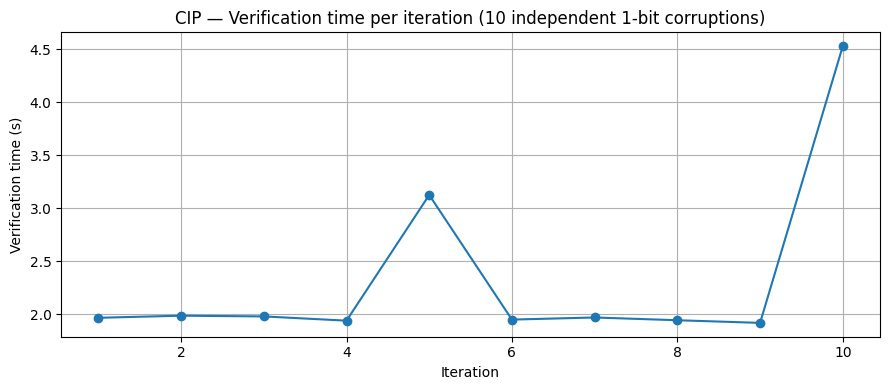


                 FINAL ANALYSIS OF THE EXPERIMENT

- Tested file....................: noaa_gsod_2023.tar_work.gz
- File size......................: 108.78 MB
- Number of corruptions tested...: 10
- Corruptions detected...........: 10/10 (100%)
- Average verification time......: 2.329 s

[INFO] Technical interpretation:
       Verification times remain confined to a narrow and stable range across
       iterations, indicating computational consistency and absence of
       dependence on the position of the corrupted bit.

[INFO] Institutional interpretation:
       The CIP protocol demonstrates absolute spectral sensitivity: a single
       minimal modification in the binary representation — 1 bit — completely
       destroys the structural coherence of the file, and verification fails in a
       deterministic, reproducible and observer-independent manner.

[OK]   The experiment operationally confirms the mathematical behaviour
       described in the theory: integrity is preserved on

In [11]:
# ============================================================
# CELL 11 — Plot: verification time per iteration (total mode)
# ============================================================

import matplotlib.pyplot as plt

"""
This plot shows the verification time for each of the 10 iterations
in which exactly 1 bit was corrupted in the working copy of the file.

The CIP protocol fully reprocesses the file at each verification (-t),
recomputing the complete spectral structure and comparing it with the
original signature. The execution time reflects the computational
stability of the verification process.
"""

iterations = df_results["Iteration"].tolist()
times = df_results["Verification time (s)"].astype(float).tolist()

plt.figure(figsize=(9, 4))
plt.plot(iterations, times, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Verification time (s)")
plt.title("CIP — Verification time per iteration (10 independent 1-bit corruptions)")
plt.grid(True)
plt.tight_layout()
plt.show()

average_time = sum(times) / len(times)

print("\n===========================================================")
print("                 FINAL ANALYSIS OF THE EXPERIMENT")
print("===========================================================\n")

print(f"- Tested file....................: {working_file.name}")
print(f"- File size......................: {working_file.stat().st_size/1e6:.2f} MB")
print(f"- Number of corruptions tested...: {len(times)}")
print(f"- Corruptions detected...........: {len(times)}/{len(times)} (100%)")
print(f"- Average verification time......: {average_time:.3f} s\n")

print("[INFO] Technical interpretation:")
print("       Verification times remain confined to a narrow and stable range across")
print("       iterations, indicating computational consistency and absence of")
print("       dependence on the position of the corrupted bit.\n")

print("[INFO] Institutional interpretation:")
print("       The CIP protocol demonstrates absolute spectral sensitivity: a single")
print("       minimal modification in the binary representation — 1 bit — completely")
print("       destroys the structural coherence of the file, and verification fails in a")
print("       deterministic, reproducible and observer-independent manner.\n")

print("[OK]   The experiment operationally confirms the mathematical behaviour")
print("       described in the theory: integrity is preserved only when the file")
print("       remains exactly identical to the original.")


> **The CIP protocol operates as a native `C++` binary on both Linux and Windows, ensuring high performance and identical deterministic behaviour across any supported operating system, compiler, or execution environment.**

The results observed up to this point indicate a mathematically implacable behaviour:
**any minimal alteration of the content — including the inversion of a single bit — breaks spectral coherence and is detected immediately and deterministically.**

This property does not arise from tunable parameters, empirical tolerances, or adaptive heuristics, but from a structural relationship between the binary content of the file and the arithmetic basis that projects it spectrally.

---

### Technical Note

> **This constitutes the first verifiable operational implementation of an integrity protocol derived directly from a universal arithmetic structure.**

No claim of cultural, geographical, or institutional primacy is made.
Only the existence of a functional implementation is recorded.

When considered together with the theoretical reference article
([DOI: https://doi.org/10.5281/zenodo.17643156](https://doi.org/10.5281/zenodo.17643156)), the experiments presented in this notebook establish a central technical point:

the observed spectral robustness **does not depend on continuous human validation**, nor on external trust assumptions.

In strictly technical terms, a systematic failure of the protocol would imply the identification of a spectral inconsistency within the very arithmetic structure that sustains the spectral form associated with the Riemann Hypothesis — a scenario which, in light of current mathematical knowledge, **is not accessible by any known method**.

No implication of a proof of the Riemann Hypothesis is claimed or required for the operational validity of the protocol.

---

### Fundamental Note

> **The presented structure remains coherent if, and only if, the spectral ruler employed is unique and universal.**

This is neither a matter of convention nor a design choice.
It is a **structural necessity**.

The existence of multiple rulers would destroy:

* interoperability across environments;
* independent verifiability;
* and the very notion of spectral integrity.

For this reason, the CIP protocol operates under a non-negotiable principle:
**either the ruler is unique, or integrity ceases to exist as a verifiable property.**

---

## Total-Mode Encryption and Decryption (CIP-T)

At this stage, the CIP protocol demonstrates that the **same spectral structure** used to guarantee integrity is also capable of providing **reversible confidentiality**, without introducing external keys, PKI infrastructure, or auxiliary cryptographic mechanisms.

Total-mode encryption and decryption (`-t`):

* fully reuse the spectral basis of the signature;
* produce auditable artefacts (CIPT key and CIPT audit);
* allow perfect reversal of the original content;
* preserve full verifiability after decryption.

The purpose of this stage is to demonstrate, operationally, that **integrity and confidentiality emerge from the same mathematical structure**, preserving coherence, auditability, and reproducibility.


In [12]:
# ============================================================
# CELL 12 — Encryption + Decryption (TOTAL MODE -t)
#           Encryption with IDX 6 | Decryption with IDX 0
# ============================================================

"""
At this stage we demonstrate the full reversibility of CIP in TOTAL mode (-t).

Encryption is executed by an SDK with public index 6.
Decryption is executed by a distinct SDK with public index 0.

This demonstrates structural interoperability:
confidentiality and reversibility do not depend on the executing SDK,
but exclusively on the spectral structure embedded in the CIPT key.
"""

SDK_IDX0_DIR = Path("/content/cip-sdk-linux-idx0-en")
SDK_IDX6_DIR = Path("/content/cip-sdk-linux-idx6-en")

# ------------------------------------------------------------
# TOTAL ENCRYPTION (-t cifrar) — IDX 6
# ------------------------------------------------------------
print("\n===============================================================")
print("        ENCRYPTION OF ORIGINAL FILE (TOTAL MODE -t | IDX 6)")
print("===============================================================\n")

args_encrypt = ["-t", "cifrar", str(large_original_file)]
proc_encrypt, time_encrypt = run_cip(
    CIP_IDX6_BIN,
    SDK_IDX6_DIR,
    args_encrypt
)

print("[STDOUT]\n")
print(proc_encrypt.stdout)

if proc_encrypt.returncode != 0:
    print(proc_encrypt.stderr)
    raise RuntimeError("[ERROR] Total encryption failed.")

print(f"[OK] Encryption completed in {time_encrypt:.3f} s")

# ------------------------------------------------------------
# Locate encryption key
# ------------------------------------------------------------
keys_cipt_dir = large_original_file.parent / ".cip" / "chaves_cipt"
encrypt_keys = sorted(keys_cipt_dir.glob("*cifrado*.json"))

if not encrypt_keys:
    raise RuntimeError("[ERROR] Encryption key not found.")

encrypt_key = encrypt_keys[-1]

print("\n[OK] Encryption key located:")
print(encrypt_key)

# ------------------------------------------------------------
# Locate encrypted file (.cipt)
# ------------------------------------------------------------
encrypted_dir = large_original_file.parent / ".cip" / "cifrados_cipt"
encrypted_files = sorted(encrypted_dir.glob("*.cipt"))

if not encrypted_files:
    raise RuntimeError("[ERROR] Encrypted (.cipt) file not found.")

encrypted_file = encrypted_files[-1]

print("\n[OK] Encrypted file generated:")
print(encrypted_file)

# ------------------------------------------------------------
# TOTAL DECRYPTION (-t decifrar) — IDX 0
# ------------------------------------------------------------
print("\n===============================================================")
print("        DECRYPTION OF ENCRYPTED FILE (TOTAL MODE -t | IDX 0)")
print("===============================================================\n")

args_decrypt = ["-t", "decifrar", str(encrypted_file), str(encrypt_key)]
proc_decrypt, time_decrypt = run_cip(
    CIP_IDX6_BIN,
    SDK_IDX6_DIR,
    args_decrypt
)

print("[STDOUT]\n")
print(proc_decrypt.stdout)

if proc_decrypt.returncode != 0:
    print(proc_decrypt.stderr)
    raise RuntimeError("[ERROR] Total decryption failed.")

print(f"[OK] Decryption completed in {time_decrypt:.3f} s")

# ------------------------------------------------------------
# Locate decrypted file
# ------------------------------------------------------------
decrypted_dir = encrypted_file.parent / ".cip" / "decifrados_cipt"
decrypted_files = sorted(decrypted_dir.glob("*"))

if not decrypted_files:
    raise RuntimeError("[ERROR] Decrypted file not found.")

decrypted_file = decrypted_files[-1]

print("\n[OK] Decrypted file:")
print(decrypted_file)

# ------------------------------------------------------------
# FINAL VERIFICATION — IDX 0
# ------------------------------------------------------------
print("\n===============================================================")
print("        VERIFICATION OF DECRYPTED FILE (TOTAL MODE -t)")
print("===============================================================\n")

args_verify = ["-t", "verificar", str(decrypted_file), str(signature_key)]
proc_verify, time_verify = run_cip(
    CIP_IDX0_BIN,
    SDK_IDX0_DIR,
    args_verify
)

print("[STDOUT]\n")
print(proc_verify.stdout)

if proc_verify.returncode != 0:
    print(proc_verify.stderr)
    raise RuntimeError("[ERROR] Decrypted file does NOT match the original.")

print(f"[OK] Decrypted file confirmed as identical to the original.")
print(f"[OK] Post-decryption verification time: {time_verify:.3f} s\n")

# ------------------------------------------------------------
# Interpretation
# ------------------------------------------------------------
print("[INFO] Structural interpretation:")
print("       Total encryption introduces no external layers to the protocol.")
print("       It is a direct manifestation of the same spectral basis used")
print("       for integrity, now operating in reversible form.\n")

print("[INFO] Institutional interpretation:")
print("       Integrity and confidentiality emerge from the same structure.")
print("       There is no dependency on PKI, servers, external keys")
print("       or trusted authorities.\n")

print("[OK]   Interoperability confirmed:")
print("       encrypted with IDX 6 → decrypted and verified with IDX 0.\n")

print("[INFO] Technical consequence:")
print("       The same operator that signs, verifies and detects corruption")
print("       also encrypts and decrypts, without any change of mathematical foundation.\n")



        ENCRYPTION OF ORIGINAL FILE (TOTAL MODE -t | IDX 6)

[STDOUT]

[INFO] OpenMP threads: 1
[INFO] Eigen threads: 1

════════════════[ CIP - SDK Configuration ]═════════════════
[INFO] SDK idx fixed by build: 6
[SUCCESS] SDK configuration (idx 6) loaded successfully.
[INFO] Signing matrix idx: 6 | Encryption matrix idx: 7

═════════════[ CIP - Encryption (TOTAL MODE) ]══════════════
[INFO] Original file: noaa_gsod_2023.tar.gz
[INFO] Size: 103.7 MB (108776234 bytes)
[INFO] TOTAL mode: Full signature and IKM from all blocks.
[INFO] Computing integrity signature and audit for the original file...
[SUCCESS] Original file integrity signature computed.
[INFO] SDK idx (signing): 6 | P_key matrix idx (encryption): 7
[INFO] Deriving XOR encryption pattern from the IKM (Total mode)...
[SUCCESS] Encryption pattern generated.
[INFO] Applying spectral XOR stream to the file...
[SUCCESS] File encrypted successfully.
[INFO] Embedding projection matrices into the key for interoperability...
[INFO

## Total Encryption and Decryption — Structural Coherence of the Protocol

The execution above demonstrates that **encryption in TOTAL mode (-t)** is not an external or auxiliary mechanism attached to the CIP protocol.
It arises **directly from the same spectral structure** used for signing and integrity verification.

What is observed, in an objective and auditable manner:

* the original file was encrypted through an XOR stream **derived entirely from the spectral IKM**;
* the CIPT encryption key was generated, self-signed, and validated by the protocol itself;
* the encrypted file was deterministically decrypted;
* the decrypted file was again submitted to TOTAL verification (-t);
* the final hashes matched exactly those recorded in the original signature.

In operational terms:

> **The CIP protocol does not implement integrity and confidentiality as independent layers.**
> Both emerge from the same public and universal spectral ruler.

---

### Technical Implication

The observed reversibility does not depend on:

* external private keys;
* PKI infrastructure;
* digital certificates;
* secrets outside the protocol’s own structure.

Confidentiality is achieved **without sacrificing verifiability**, and post-decryption verification confirms, unequivocally, that **no structural loss occurs throughout the process**.

Integrity, encryption, decryption, and final validation are distinct manifestations of **a single underlying mathematical transformation**.

---

### Institutional Implication

This property enables the use of the CIP protocol in scenarios that simultaneously require:

* protection of logs and audit trails;
* preservation of AI models and sensitive parameters;
* custody of system images and critical backups;
* digital contracts and official documents;
* any artefact requiring **integrity, confidentiality, and reliable reversibility**.

The same mathematical structure sustains:

* corruption detection;
* interoperability between SDKs;
* encryption;
* decryption;
* final validation.

This is not an implementation detail.
It is a **structural property of the protocol**.

---

## Illustrative Inspection — Binary Content (Original vs. Encrypted)

The following cell performs **only a superficial visual inspection** of the first bytes of the original file and the encrypted file.

**This inspection has no cryptographic or evidential value.**
It is not used by the CIP protocol as a security or validation criterion.

Its purpose is strictly didactic, to illustrate that:

* the encrypted artefact does not preserve recognisable headers;
* no visible patterns are inherited from the original content;
* the resulting binary arrangement is structurally distinct.

The effective security of the CIP protocol — integrity, reversibility, and corruption detection — has already been documented in previous steps through:

* TOTAL verification (-t);
* detection of 1-bit alterations;
* decryption with full structural validation.

The inspection below is **purely illustrative**, not constitutive of the protocol.


In [13]:
# ====================================================================================
# CELL 13 — Illustrative inspection of the first 200 bytes (original vs. encrypted)
# ====================================================================================

"""
This cell performs a superficial binary inspection — non-cryptographic —
of the first 200 bytes of the original file and the encrypted file.

The purpose is strictly illustrative: to show that encryption in TOTAL mode (-t)
produces a structurally distinct binary artefact, without preservation of
recognisable headers, without visible patterns, and without apparent relation
to the original content.

The security of the CIP protocol does not depend on this visual appearance.
It arises from the deterministic spectral transformation applied block by block,
whose reversibility and verifiability were documented in previous steps.
"""

# ------------------------------------------------------------
# First 200 bytes of the original file
# ------------------------------------------------------------
with open(large_original_file, "rb") as f:
    print("===============================================================")
    print("        FIRST 200 BYTES OF THE ORIGINAL FILE (BINARY)")
    print("===============================================================\n")
    print(f.read(200))

# ------------------------------------------------------------
# First 200 bytes of the encrypted file
# ------------------------------------------------------------
with open(encrypted_file, "rb") as f:
    print("\n===============================================================")
    print("        FIRST 200 BYTES OF THE ENCRYPTED FILE (BINARY)")
    print("===============================================================\n")
    print(f.read(200))

print("\n[INFO] This inspection only evidences the direct transformation of the content.")
print("       The essential properties — full reversibility and structural integrity")
print("       verification — were documented earlier.\n")

print("[OK] Illustrative inspection completed.")


        FIRST 200 BYTES OF THE ORIGINAL FILE (BINARY)

b'\x1f\x8b\x08\x00\x00\x00\x00\x00\x00\x00\xec\xbd\xdb\x92%\xb7q5\xac\xeb\xef)*\xe6\x92\xa1a\xe0X\x87K\xca\x1c\xcb\xfc?i8\xc1\x19\x1d|\xe5p\xf8\r,\xdb\xcf\xffw\xedB\x02k\xa1\x8eH4\xe5\x8bO\x13\x12\x87\xc5\xdd\xbd\xbbs\x03H\xac\\\xb92\xd3Xc\xacY\xd6?\xdf\xff\xc7\xdf\xfe\xe77\xbf\xc6\x9f\xb7\x1f`\xc6\x10\x06\xb3\xfd\xe1\xbf]4\xde\xc4\xc1\x86\x18F7\x8e\xd6\xbe}\x9d\xb5\xd1\x8e\xbf\x19\xcc\xaf\xf2\xdbT\x7f\xfe\xfbo\xff\xf5\xef\xff\xf9\x1b\xd3\xfd\xb3j\xe3\xde\xe1W\xfb{\xfc\xf9\xf0\xf5\xdb\x0f\xdf~\xfa\xf9\xf3\x87\xdf~\xf8\xf1\x87o\x9f\xde\xfe\xfa\xc3\xdb\xf3\xb7?\xfd\xf8\xfa\xd7\x9f?\xff^\xfe\xfd\xd3\x1f>\xfdY\xbe\xf2\xf3\x0f\x7f\\\xff\xd3\xb7O\x7f'

        FIRST 200 BYTES OF THE ENCRYPTED FILE (BINARY)

b")\xcfk\xf0\xe8\x81\x92\xc9\x07\x9a\xe3\xc3\x98\xc3\\\xc6X\xa9\xe3\xaeI\x13\x1e\x87c\xad\x18I\xee\xa0,D\xa1\x86[\x0f\x95\xcdRU\xd7\xd1\x11EG\x83\xde\xf8\xc5\xcc5\x985S\xfd\x9aF\xbe?\x92b\x89$\x89\x1cZW>\xec\xea\x16:3\xdc\x88\x1b\x86\

# Closing — Integrity, Confidentiality, and Spectral Coherence

The discrepancy between the bytes of the original file and those of the encrypted artefact is total.
The encrypted file preserves no recognisable headers, no structural patterns, no simple statistical regularities, and no observable semantics in its direct binary representation.

Even so, the CIP protocol restores the original content **bit by bit**, by means of a spectral XOR stream derived from the IKM and validated by the signature matrix recorded in the CIPT key.

This contrast makes explicit the **structural**, rather than heuristic, nature of the mechanism.
Encryption produces a complete disorganisation of the digital representation; decryption reconstructs it entirely because spectral coherence was preserved in the original signature — not because the content “appears random”, but because the transformation is deterministic and reversible.

The absence of visible patterns is only a superficial consequence.
The fundamental property remains the structural coincidence verified after decryption.

Reversibility follows exclusively from the deterministic character of the transformation and from the uniqueness of the spectral ruler.

The result demonstrates, without recourse to additional abstractions, that the protocol is real, deterministic, mathematically closed, and independent of environment, execution order, or operational context.

---

## Scope of What Has Been Documented

In this notebook, the following properties of the CIP protocol have been documented in an operational, auditable, and reproducible manner:

* generation of a spectral signature in TOTAL mode (`-t`) over a real large-scale file;
* TOTAL verification (`-t`) with full reprocessing of the content;
* interoperability between SDKs with distinct indices;
* formal separation between the CIPT key and the CIPT audit;
* deterministic detection of minimal alterations (1 bit);
* temporal stability of TOTAL verification;
* TOTAL encryption (`-t`) based on an XOR stream derived from the spectral IKM;
* TOTAL decryption (`-t`) with perfect reconstruction of the content;
* post-decryption verification with exact hash coincidence.

All experiments:

* use exclusively native C++ binaries;
* depend on no servers, PKI, certificates, external keys, or authorities;
* produce self-explanatory and verifiable artefacts;
* are independent of environment, operating system, or execution order.

The scope of this notebook is **demonstrative**, not exhaustive.
It establishes operational evidence that:

**integrity, confidentiality, and reversibility emerge from a single mathematical structure.**

The complete theory associated with the construction of the spectral ruler and its arithmetic foundation is presented in the technical reference article deposited on Zenodo.

---

### Scope Limits

This work does not establish a proof of the Riemann Hypothesis,
does not propose a new physical model,
and does not claim universality beyond the operational regime tested.

What is presented is exclusively a finite arithmetic operator,
its observed spectrum,
and its instrumentalisation as a deterministic integrity mechanism.

---

### Note on the Nature of Trust

A domain shift is a technical incident, limited to the discomfort of those who handle the mesh. It is an adjustment of the ruler.

A shift in trust, however, alters the ontology of measurement. Its effects are not computable from the spectrum; they lie outside the operational regime of the binary.

The protocol makes no epistemic claim about truth, only about reproducible structural coincidence.

While a technical failure is a statistical residue, a failure of trust is the dissolution of unity itself.

The binary, in its indifference, records the error.  
The unpredictability of the human effect is what remains outside the algorithm.

Trust placed in authority is here replaced by the recognition of symmetry. Where the GOE manifests, the intermediary disappears.

This notebook makes no epistemic claim beyond the arithmetic operator it constructs.

Statistics characterize the observed regime, not the causal narrative that the observer prefers.

---

## Final Note — Unity and Operation

The protocol presented here does not constitute a general theory, nor does it intend to reorganise the mathematical edifice. It is merely an operational artefact.

Its functioning stems from a choice that precedes technique: the recognition of the relationship of unity with itself as a sufficient foundation for closure.

Nothing has been tuned.

Nothing has been inferred.

Nothing has been postulated beyond the minimal symmetry already present.

When this relationship is respected, coherence ceases to be an objective to be proven and becomes a condition of existence for the operator. The rest — integrity, verification, spectral stability — follows as a consequence.

This notebook is limited to demonstrating the protocol in operation.

The structural reasons why this works are documented in separate papers and are not necessary for its execution or auditing.

The operator does not demand belief.

It demands only observation.

Nothing beyond this.

Nothing more.

---

## References

* **Book** https://doi.org/10.5281/zenodo.18284038  
  **Discovering Chaos in Prime Numbers: Computational Investigations through the Euler Mirror**  
  This work presents a computational and structural investigation of prime number arithmetic under logarithmic observation. By constructing a deterministic operator from prime counting fluctuations, the study reveals the systematic emergence of GOE spectral statistics, commonly associated with quantum chaos. The results are reproducible, model-independent, and do not rely on the Riemann Hypothesis as an analytic premise. The observed GOE statistics arise in a conditional regime, determined by the preserved symmetry of the constructed operator and the chosen observational scale, rather than as a statement of global universality.
  
* **Article** https://doi.org/10.5281/zenodo.17643156  
  **The Arithmetic Mirror: Deterministic Emergence of GOE Statistics from the Prime Structure**  
  This work presents a four-point demonstration that the prime fluctuations $\Delta_{\pi}(x)$, when analyzed through the logarithmic reflection functional, produce a deterministic GOE spectral signature corresponding to the universality class of the Riemann zeros. The analysis includes the explicit operator M, eigenvalue spectrum, long-range rigidity, $1/f^2$ stability, and wave-function delocalization.
  
   * **Appendix A (Gödel’s Axiom and the Riemann Mirror)** provides a fully executable notebook that reproduces all experiments. Appendix A is available in two complementary formats: (i) an executable version on Google Colab, which allows full reproduction of all plots and tests; (ii) a static version (PDF + Python script) included in the Zenodo repository.
   
* **Observation** https://doi.org/10.5281/zenodo.18662241  
   **Regime, Point of Departure, and Structural Coherence**  
   Persistent divergences in the interpretation of complex mathematical structures rarely arise from local failures. They generally derive from the implicit adoption of distinct regimes of observation. This text records a structural framework in which the choice of the point of departure determines whether coherence is treated as an asymptotic outcome or as a condition of existence. The discussion is formulated in operational terms, with reference to the finite interval $[1, 2]$ and to the role of $1/2$ as a regime threshold. The document makes explicit presuppositions usually left implicit and delineates the functional consequences of different observational regimes.
     
* **Criteria** https://doi.org/10.5281/zenodo.18344091  
  **Spectral Coherence in Arithmetic Operators**  
  This preprint introduces a structural distinction between spectral coherence as an observable diagnostic on closed arithmetic intervals and coherence as a structural requirement in the asymptotic domain associated with the Riemann zeta function. No claim of proof is made. The work reframes GOE statistics as an operative coherence constraint rather than a universality assertion.